# Домашнее задание №2

# 1. EDA

In [96]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path(".")
df = pd.read_csv(DATA_DIR / "train.csv")

df.head()

,ID,target,48df886f9,0deb4b6a8,34b15f335,a8cb14b00,2f0771a37,30347e683,d08d1fbe3,6ee66e115,...,3ecc09859,9281abeea,8675bec0b,3a13ed79a,f677d4d13,71b203550,137efaa80,fb36b89d9,7e293fbaf,9fc776466
0,000d6aaf2,38000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
1,000fbd867,600000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
2,0027d6b71,10000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,0028cbf45,2000000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,002a68644,14400000.0,0.0,0,0.0,0,0,0,0,0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [97]:
df.shape

(4459, 4993)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4459 entries, 0 to 4458
Columns: 4993 entries, ID to 9fc776466
dtypes: float64(1845), int64(3147), object(1)
memory usage: 169.9+ MB


## 1.1. Пропуски и простые свойства признаков

In [99]:
target_col = "target"
id_col = "ID"
feature_cols = [c for c in df.columns if c not in [id_col, target_col]]

print(f"Строк: {len(df):,}")
print(f"Признаков: {len(feature_cols):,}")
print(f"Пропусков во всей таблице: {df.isna().sum().sum():,}")
print(f"Постоянных признаков: {(df[feature_cols].nunique(dropna=False) <= 1).sum():,}")

Строк: 4,459
Признаков: 4,991
Пропусков во всей таблице: 0
Постоянных признаков: 256


In [100]:
df[target_col].describe(percentiles=[0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_frame()

,target
count,4.459000e+03
mean,5.944923e+06
std,8.234312e+06
min,3.000000e+04
1%,3.500000e+04
10%,1.595556e+05
25%,6.000000e+05
50%,2.260000e+06
75%,8.000000e+06
90%,2.000000e+07


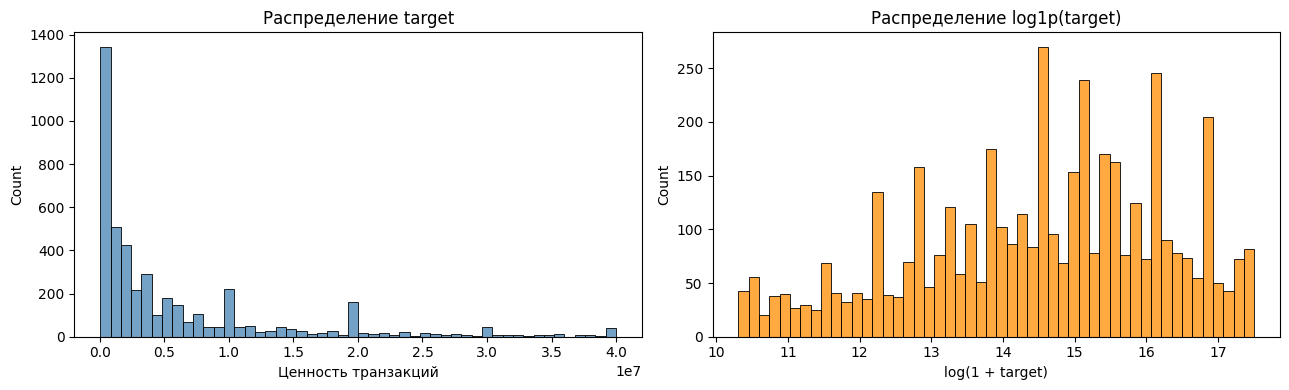

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df[target_col], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Распределение target")
axes[0].set_xlabel("Ценность транзакций")

sns.histplot(np.log1p(df[target_col]), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Распределение log1p(target)")
axes[1].set_xlabel("log(1 + target)")

plt.tight_layout()
plt.show()

Теперь немного про признаки. Их 4000+ и все они не имеют какого то названия, которое несло бы смысловую нагрузку. Поэтому мы имеем просто гору непонятных признаков. Я решил почитать в обсуждениях на кагле. Там люди предполагают, что датасет состоит из пересекающихся временных рядов. Но это лишь предположение. И у большиснтва была суть искать закономерности уже в самой базе и пытаться предстаказывть таргет таким образом (при этом используя еще и градиентный бустинг). Но сначала все таки попробуем как будут работать алгоритмы обучения без доп поисков. 

## 1.2 Feature engineering

Поэтому пока что сделаем вот что:
- мы не будем удалять никакие признаки, не смотря на то что есть 250 постоянных признаков
- добавим агрегированные по строке признаки (число ненулевых, среднее и отклонение) причем именно ненулевые 


In [102]:
X_base = df.drop(columns=["ID", "target"])

nonzero_mask = X_base.ne(0)
nonzero_values = X_base.where(nonzero_mask)

aggregate_features = pd.DataFrame({
    # Сколько признаков ненулевые у клиента
    "nonzero_count": nonzero_mask.sum(axis=1),

    # Среднее только по ненулевым признакам
    "nonzero_mean": nonzero_values.mean(axis=1).fillna(0),

    # Разброс только среди ненулевых признаков
    "nonzero_std": nonzero_values.std(axis=1, ddof=0).fillna(0),
}, index=df.index)

X_model = pd.concat([X_base, aggregate_features], axis=1)
y = df["target"]

print("Итоговый размер матрицы признаков:", X_model.shape)

aggregate_features.head()

Итоговый размер матрицы признаков: (4459, 4994)


,nonzero_count,nonzero_mean,nonzero_std
0,102,7.066356e+06,9.970794e+06
1,67,7.939801e+06,1.058251e+07
2,18,4.233333e+06,3.548396e+06
3,22,1.517758e+06,2.134919e+06
4,26,6.872846e+06,9.545291e+06


,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
nonzero_count,4459.0,157.01,212.09,1.0,11.00,34.00,103.00,197.00,319.00,1069.42,1.989000e+03
nonzero_mean,4459.0,9841898.44,14596194.10,4000.0,857570.17,2313470.44,6082092.77,12059056.87,21276675.97,60000000.00,4.000000e+08
nonzero_std,4459.0,13279990.15,22281268.97,0.0,759733.11,2661933.80,8271001.35,17066142.97,27430531.70,89463975.83,3.095760e+08


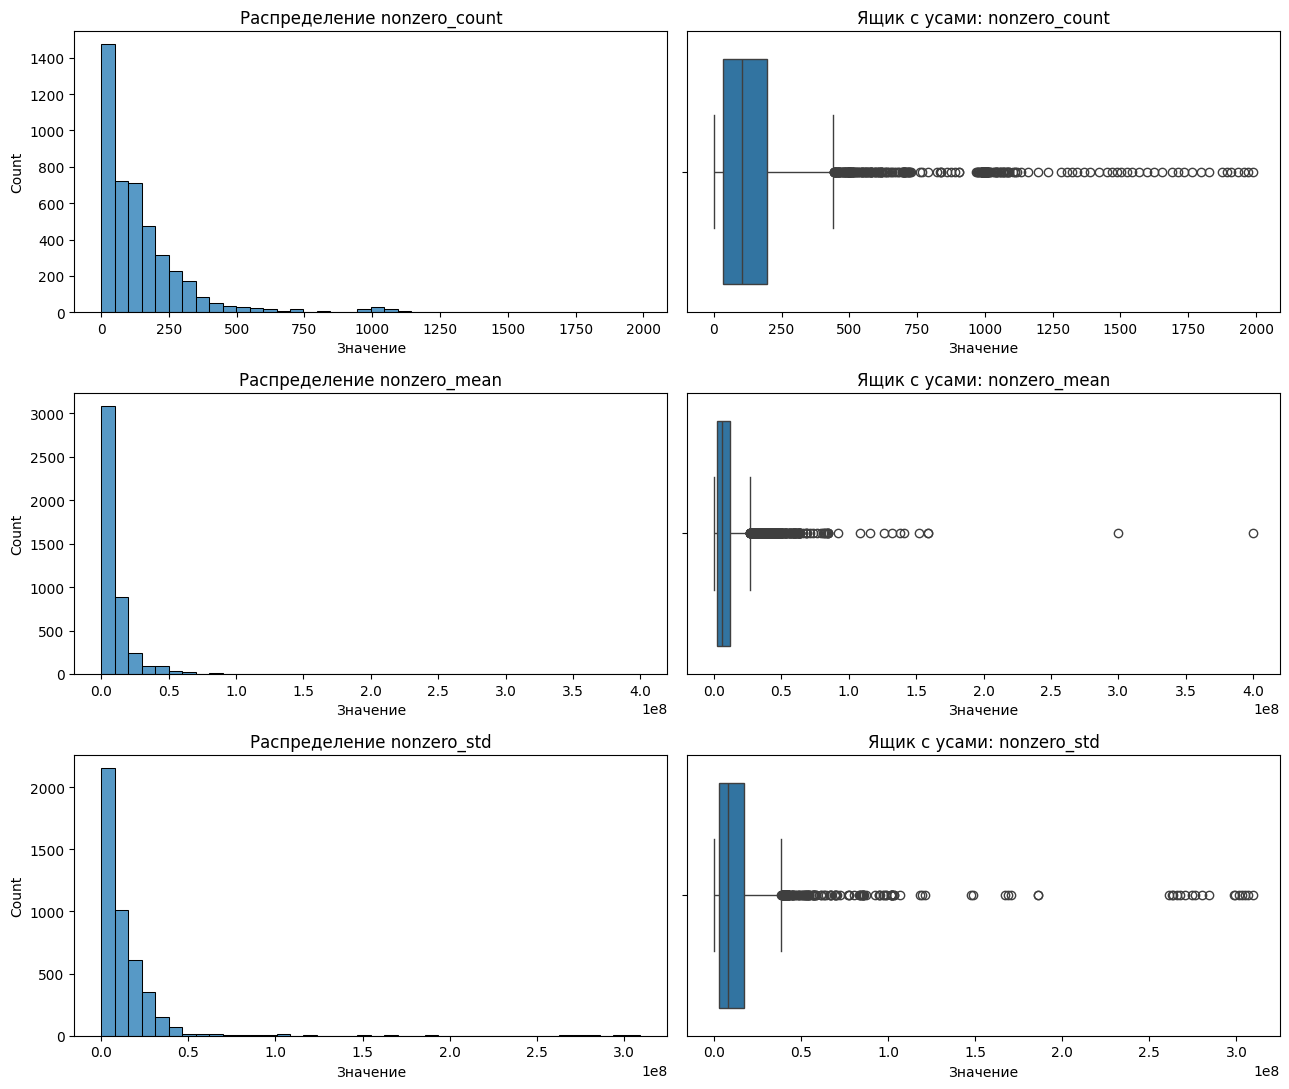

,Корреляция Спирмена с target
nonzero_count,-0.045
nonzero_mean,0.504
nonzero_std,0.308


In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

columns = ["nonzero_count", "nonzero_mean", "nonzero_std"]


display(
    aggregate_features[columns]
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99])
    .T
    .round(2)
)

fig, axes = plt.subplots(3, 2, figsize=(13, 11))

for row, col in enumerate(columns):
    sns.histplot(aggregate_features[col], bins=40, ax=axes[row, 0])
    axes[row, 0].set_title(f"Распределение {col}")
    axes[row, 0].set_xlabel("Значение")

    sns.boxplot(x=aggregate_features[col], ax=axes[row, 1])
    axes[row, 1].set_title(f"Ящик с усами: {col}")
    axes[row, 1].set_xlabel("Значение")

plt.tight_layout()
plt.show()

# Предварительная связь каждого агрегата с target
spearman = aggregate_features[columns].corrwith(
    df["target"],
    method="spearman"
)

display(spearman.to_frame("Корреляция Спирмена с target").round(3))

Теперь разберемся с baseline

## 2. Baseline

Сначала посмотрим на метрику, с которой будем работать:

$$
\mathrm{RMSLE}
=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left[
\ln(1+\hat{y}_i)-\ln(1+y_i)
\right]^2
}
$$

Где:

- $n$ — количество объектов, для которых оценивается прогноз;
- $y_i$ — настоящее значение `target` для объекта $i$;
- $\hat{y}_i$ — предсказанное значение `target`;
- $\ln$ — натуральный логарифм.

**Чем меньше RMSLE, тем лучше.** Значение 0 означает, что предсказания полностью совпали с настоящими значениями.

Сначала проверим просто констатнту и Ридж регрессию. Дальше уже будем отталкиваться от них

In [104]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    random_state=42
)

constant = np.expm1(np.log1p(y_train).mean())
constant_pred = np.full(len(y_test), constant)

constant_rmsle = np.sqrt(
    np.mean(
        (np.log1p(y_test.to_numpy()) - np.log1p(constant_pred)) ** 2
    )
)

print(f"Постоянный прогноз: {constant:,.2f}")
print(f"RMSLE константы: {constant_rmsle:.4f}")

Постоянный прогноз: 1,964,498.59
RMSLE константы: 1.6963


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_model = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(alpha=100.0, solver="lsqr")
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

# Для RMSLE прогнозы должны быть неотрицательными (они могут быть отрицательными из-за Ridge)
ridge_pred = np.maximum(ridge_pred, 0)

ridge_rmsle = np.sqrt(
    np.mean(
        (np.log1p(y_test.to_numpy()) - np.log1p(ridge_pred)) ** 2
    )
)

print(f"RMSLE константы: {constant_rmsle:.4f}")
print(f"RMSLE Ridge:     {ridge_rmsle:.4f}")


RMSLE константы: 1.6963
RMSLE Ridge:     6.9256


Очень плохо. Теперь проделаем работу по поиску гиперпараметров для Ридж. И на лучшей протестируем.

In [106]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import make_scorer

def rmsle_with_clip(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(
        np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2)
    )

ridge_pipeline = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(solver="lsqr")
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(
    ridge_pipeline,
    param_grid={"ridge__alpha": [0.01, 1, 100, 10_000, 1_000_000]},
    scoring=make_scorer(rmsle_with_clip, greater_is_better=False),
    cv=cv,
    n_jobs=1
)

search.fit(X_train, y_train)

for alpha, score in zip(
    search.cv_results_["param_ridge__alpha"],
    search.cv_results_["mean_test_score"]
):
    print(f"alpha={alpha:>10}: CV RMSLE={-score:.4f}")

print(f"\nЛучшее alpha: {search.best_params_['ridge__alpha']}")
print(f"Лучшее CV RMSLE: {-search.best_score_:.4f}")

alpha=      0.01: CV RMSLE=9.6358
alpha=       1.0: CV RMSLE=9.0821
alpha=     100.0: CV RMSLE=6.8210
alpha=   10000.0: CV RMSLE=3.8466
alpha= 1000000.0: CV RMSLE=2.4796

Лучшее alpha: 1000000
Лучшее CV RMSLE: 2.4796


In [107]:
best_ridge_pred = search.predict(X_test)
test_rmsle = rmsle_with_clip(y_test.to_numpy(), best_ridge_pred)

print(f"RMSLE константы: {constant_rmsle:.4f}")
print(f"RMSLE Ridge после подбора: {test_rmsle:.4f}")

RMSLE константы: 1.6963
RMSLE Ridge после подбора: 2.2450


Все же Ридж проигрывает пока даже константе. Это плохо. Очень...

Попробуем обучить ридж предсказывать таргет в форме log(1 + target). Мне кажется, что большие значения таргета мешают обучению

In [159]:
def rmse_on_log_target(y_true_log, y_pred_log):
    # target неотрицательный, поэтому прогноз в log1p-шкале не должен быть меньше нуля
    y_pred_log = np.maximum(y_pred_log, 0)

    return np.sqrt(
        np.mean((y_true_log - y_pred_log) ** 2)
    )

ridge_pipeline = make_pipeline(
    StandardScaler(with_mean=False),
    Ridge(solver="lsqr")
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

search_log = GridSearchCV(
    ridge_pipeline,
    param_grid={
        "ridge__alpha": [0.01, 1, 100, 10_000, 1_000_000]
    },
    scoring=make_scorer(
        rmse_on_log_target,
        greater_is_better=False
    ),
    cv=cv,
    n_jobs=1
)

y_train_log = np.log1p(y_train)

search_log.fit(X_train, y_train_log)

for alpha, score in zip(
    search_log.cv_results_["param_ridge__alpha"],
    search_log.cv_results_["mean_test_score"]
):
    print(f"alpha={alpha:>10}: CV RMSLE={-score:.4f}")

print(f"\nЛучшее alpha: {search_log.best_params_['ridge__alpha']}")
print(f"Лучшее CV RMSLE: {-search_log.best_score_:.4f}")

alpha=      0.01: CV RMSLE=538.1270
alpha=       1.0: CV RMSLE=484.0929
alpha=     100.0: CV RMSLE=233.9932
alpha=   10000.0: CV RMSLE=19.7634
alpha= 1000000.0: CV RMSLE=2.0154

Лучшее alpha: 1000000
Лучшее CV RMSLE: 2.0154


In [161]:
test_pred_log = search_log.predict(X_test)
test_pred_log = np.maximum(test_pred_log, 0)

test_pred = np.expm1(test_pred_log)

test_rmsle = np.sqrt(
    np.mean(
        (np.log1p(y_test.to_numpy()) - np.log1p(test_pred)) ** 2
    )
)

print(f"RMSLE константы: {constant_rmsle:.4f}")
print(f"RMSLE Ridge с log1p(target): {test_rmsle:.4f}")

RMSLE константы: 1.6963
RMSLE Ridge с log1p(target): 1.9841


Уже лучше, проверим еще большие значения для alpha

In [162]:
search_log.param_grid = {
    "ridge__alpha": [1_000_000, 10_000_000, 100_000_000, 1_000_000_000]
}

search_log.fit(X_train, y_train_log)

for alpha, score in zip(
    search_log.cv_results_["param_ridge__alpha"],
    search_log.cv_results_["mean_test_score"]
):
    print(f"alpha={alpha:>12}: CV RMSLE={-score:.4f}")

print(f"\nЛучшее alpha: {search_log.best_params_['ridge__alpha']}")
print(f"Лучшее CV RMSLE: {-search_log.best_score_:.4f}")

alpha=     1000000: CV RMSLE=2.0154
alpha=    10000000: CV RMSLE=1.8123
alpha=   100000000: CV RMSLE=1.7657
alpha=  1000000000: CV RMSLE=1.7645

Лучшее alpha: 1000000000
Лучшее CV RMSLE: 1.7645


In [111]:
best_ridge_pred_log = search_log.predict(X_test)
best_ridge_pred_log = np.maximum(best_ridge_pred_log, 0)

best_ridge_pred = np.expm1(best_ridge_pred_log)

best_ridge_test_rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(y_test.to_numpy())
            - np.log1p(best_ridge_pred)
        ) ** 2
    )
)

print(f"Лучшая alpha: {search_log.best_params_['ridge__alpha']}")
print(f"RMSLE Ridge на X_test: {best_ridge_test_rmsle:.4f}")

Лучшая alpha: 1000000000
RMSLE Ridge на X_test: 1.6963


Итог:
- мы достигли оценки как у константы, но нам пришлось сильно увеличить альфа.
- это говорит о том, что Ридж сильно подстраиваться и сильно зануляет веса, что по факту приближает его к константе
- оценка ридж и константы еще очень далека от результата, чтобы попасть в топ-25%

Проверим, сможет ли рэндом форест уловить нелинейные зависимости и улучшить метрику

In [112]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_leaf=5,
    max_features=0.1,
    n_jobs=-1,
    random_state=42
)

rf_cv_scores = -cross_val_score(
    rf_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=1
)

print(f"CV RMSLE: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

CV RMSLE: 1.4195 ± 0.0170


In [113]:
rf_model.fit(X_train, y_train_log)

rf_pred_log = rf_model.predict(X_test)

rf_test_rmsle = np.sqrt(
    np.mean(
        (np.log1p(y_test.to_numpy()) - rf_pred_log) ** 2
    )
)

print(f"RMSLE константы: {constant_rmsle:.4f}")
print(f"RMSLE Random Forest: {rf_test_rmsle:.4f}")

RMSLE константы: 1.6963
RMSLE Random Forest: 1.3913


Отлично. Мы уверенно победили константу. Теперь сделаем гридсерч по параметрам леса.

Так как это достаточно долго и трудоемко, посмотрим, какой из параметров окажет болшее влияние.

In [114]:
rf_params = [
    # Уже проверенная конфигурация
    {
        "max_depth": [12],
        "min_samples_leaf": [5],
        "max_features": [0.1],
    },
    # Глубина дерева
    {
        "max_depth": [8, 16],
        "min_samples_leaf": [5],
        "max_features": [0.1],
    },
    # Минимальное число строк в листе
    {
        "max_depth": [12],
        "min_samples_leaf": [2, 10],
        "max_features": [0.1],
    },
    # Доля признаков при поиске разделения
    {
        "max_depth": [12],
        "min_samples_leaf": [5],
        "max_features": [0.05, 0.2],
    },
]

rf_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=1
)

rf_search.fit(X_train, y_train_log)

for params, score in zip(
    rf_search.cv_results_["params"],
    rf_search.cv_results_["mean_test_score"]
):
    print(f"CV RMSLE={-score:.4f} | {params}")

print(f"\nЛучшие параметры: {rf_search.best_params_}")
print(f"Лучшее CV RMSLE: {-rf_search.best_score_:.4f}")

CV RMSLE=1.4195 | {'max_depth': 12, 'max_features': 0.1, 'min_samples_leaf': 5}
CV RMSLE=1.4584 | {'max_depth': 8, 'max_features': 0.1, 'min_samples_leaf': 5}
CV RMSLE=1.4066 | {'max_depth': 16, 'max_features': 0.1, 'min_samples_leaf': 5}
CV RMSLE=1.4232 | {'max_depth': 12, 'max_features': 0.1, 'min_samples_leaf': 2}
CV RMSLE=1.4265 | {'max_depth': 12, 'max_features': 0.1, 'min_samples_leaf': 10}
CV RMSLE=1.4585 | {'max_depth': 12, 'max_features': 0.05, 'min_samples_leaf': 5}
CV RMSLE=1.4095 | {'max_depth': 12, 'max_features': 0.2, 'min_samples_leaf': 5}

Лучшие параметры: {'max_depth': 16, 'max_features': 0.1, 'min_samples_leaf': 5}
Лучшее CV RMSLE: 1.4066


In [163]:
best_rf_pred_log = rf_search.predict(X_test)

best_rf_test_rmsle = np.sqrt(
    np.mean(
        (np.log1p(y_test.to_numpy()) - best_rf_pred_log) ** 2
    )
)

print(f"RMSLE константы: {constant_rmsle:.4f}")
print(f"RMSLE первого леса: {rf_test_rmsle:.4f}")
print(f"RMSLE леса после подбора: {best_rf_test_rmsle:.4f}")

RMSLE константы: 1.6963
RMSLE первого леса: 1.3913
RMSLE леса после подбора: 1.3759


Посмотрим на выжность признаков после рэндом фореста

,важность,место
nonzero_mean,0.209706,1
nonzero_std,0.068261,2
nonzero_count,0.026414,4


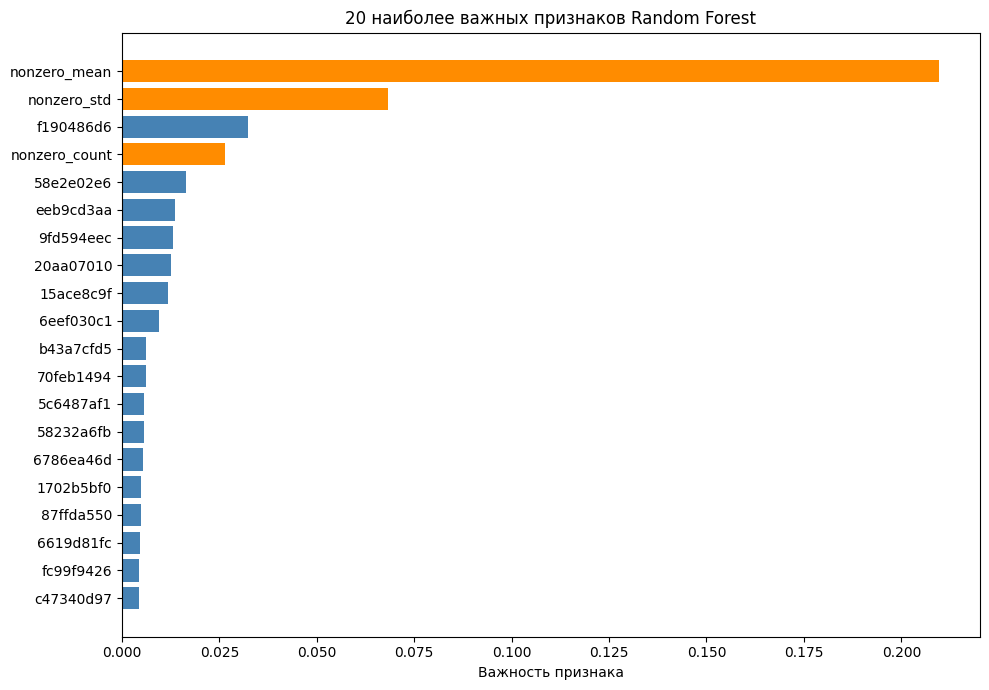

In [116]:
aggregate_names = ["nonzero_count", "nonzero_mean", "nonzero_std"]

rf_importance = pd.Series(
    rf_search.best_estimator_.feature_importances_,
    index=X_train.columns,
    name="importance"
).sort_values(ascending=False)

rf_ranks = rf_importance.rank(
    ascending=False,
    method="min"
).astype(int)

display(
    pd.DataFrame({
        "важность": rf_importance.reindex(aggregate_names),
        "место": rf_ranks.reindex(aggregate_names),
    }).sort_values("место")
)

top_20 = rf_importance.head(20).iloc[::-1]
colors = [
    "darkorange" if name in aggregate_names else "steelblue"
    for name in top_20.index
]

plt.figure(figsize=(10, 7))
plt.barh(top_20.index, top_20.values, color=colors)
plt.xlabel("Важность признака")
plt.title("20 наиболее важных признаков Random Forest")
plt.tight_layout()
plt.show()

Видим, что добавленные признаки имеют высокую важность. Особенно nonzero_mean. На мой взгляд это первый сигнал, что данные как то связаны с какими то рядами и законгомерностями в порядке. Но это чисто отдаленно, понятно что это вообще особо не связано

Сделаем все таки полноценный грид серч для рэндом фореста

In [164]:
rf_grid_params = {
    "max_depth": [16, 24, None],
    "min_samples_leaf": [2, 5, 10],
    "max_features": [0.1, 0.2, 0.3],
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_grid_params,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    verbose=2
)

rf_grid_search.fit(X_train, y_train_log)

rf_grid_results = pd.DataFrame({
    "max_depth": [
        params["max_depth"]
        for params in rf_grid_search.cv_results_["params"]
    ],
    "min_samples_leaf": [
        params["min_samples_leaf"]
        for params in rf_grid_search.cv_results_["params"]
    ],
    "max_features": [
        params["max_features"]
        for params in rf_grid_search.cv_results_["params"]
    ],
    "CV RMSLE": -rf_grid_search.cv_results_["mean_test_score"],
    "CV std": rf_grid_search.cv_results_["std_test_score"],
    "Train RMSLE": -rf_grid_search.cv_results_["mean_train_score"],
})

rf_grid_results = rf_grid_results.sort_values("CV RMSLE")

display(rf_grid_results.head(10).round(4))

print("Лучшие параметры:", rf_grid_search.best_params_)
print(f"Предыдущее лучшее CV RMSLE: {-rf_search.best_score_:.4f}")
print(f"Новое лучшее CV RMSLE:     {-rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.5s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.2s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.2s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.1s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.1s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.1s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.2s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.2s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.0s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.0s
[CV] END max_depth=16, max_features=0.1, min_samples_leaf=10; total time=   0.9s
[CV] END max_depth=16, max_features=0.1, min_sa

,max_depth,min_samples_leaf,max_features,CV RMSLE,CV std,Train RMSLE
25,NaN,5,0.3,1.3738,0.0204,0.8979
16,24.0,5,0.3,1.3768,0.0188,0.9324
15,24.0,2,0.3,1.3773,0.0187,0.7512
22,NaN,5,0.2,1.3792,0.0164,0.9239
12,24.0,2,0.2,1.3799,0.0205,0.7787
24,NaN,2,0.3,1.3802,0.0194,0.6230
18,NaN,2,0.1,1.3805,0.0211,0.6716
6,16.0,2,0.3,1.3814,0.0187,0.9160
26,NaN,10,0.3,1.3817,0.0212,1.0951
21,NaN,2,0.2,1.3820,0.0190,0.6381


Лучшие параметры: {'max_depth': None, 'max_features': 0.3, 'min_samples_leaf': 5}
Предыдущее лучшее CV RMSLE: 1.4066
Новое лучшее CV RMSLE:     1.3738


In [165]:
rf_grid_pred_log = rf_grid_search.predict(X_test)

rf_grid_test_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    rf_grid_pred_log
)

print(f"RMSLE константы:          {constant_rmsle:.4f}")
print(f"RMSLE предыдущего леса:   {best_rf_test_rmsle:.4f}")
print(f"RMSLE расширенного леса: {rf_grid_test_rmsle:.4f}")

RMSLE константы:          1.6963
RMSLE предыдущего леса:   1.3759
RMSLE расширенного леса: 1.3574


## 3. LightGBM

In [118]:
%pip install lightgbm


[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [166]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgb_cv_scores = -cross_val_score(
    lgb_model,
    X_train,
    y_train_log,
    cv=cv,
    scoring=make_scorer(
        rmse_on_log_target,
        greater_is_better=False
    ),
    n_jobs=1
)

print(
    f"LightGBM CV RMSLE: "
    f"{lgb_cv_scores.mean():.4f} ± {lgb_cv_scores.std():.4f}"
)

LightGBM CV RMSLE: 1.4053 ± 0.0242


In [167]:
lgb_model.fit(X_train, y_train_log)

lgb_pred_log = np.maximum(lgb_model.predict(X_test), 0)

lgb_test_rmsle = np.sqrt(
    np.mean(
        (np.log1p(y_test.to_numpy()) - lgb_pred_log) ** 2
    )
)

print(f"RMSLE константы: {constant_rmsle:.4f}")
print(f"RMSLE Random Forest: {rf_grid_test_rmsle:.4f}")
print(f"RMSLE LightGBM: {lgb_test_rmsle:.4f}")

RMSLE константы: 1.6963
RMSLE Random Forest: 1.3574
RMSLE LightGBM: 1.3988


Пока градиентный бустинг не превзошел рэндом форест. Сделаем тоже подбор параметров для бустинга

In [168]:
from sklearn.model_selection import RandomizedSearchCV

lgb_search = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions={
        "n_estimators": [100, 250, 400],
        "learning_rate": [0.03, 0.05, 0.1],
        "num_leaves": [7, 15, 31],
        "min_child_samples": [10, 20, 50],
        "colsample_bytree": [0.5, 0.8, 1.0],
    },
    n_iter=10,
    scoring=make_scorer(
        rmse_on_log_target,
        greater_is_better=False
    ),
    cv=cv,
    random_state=42,
    n_jobs=1,
    return_train_score=True
)

lgb_search.fit(X_train, y_train_log)

print("Лучшие параметры:", lgb_search.best_params_)
print(f"Лучшее CV RMSLE: {-lgb_search.best_score_:.4f}")

best_i = lgb_search.best_index_
train_rmsle = -lgb_search.cv_results_["mean_train_score"][best_i]
print(f"RMSLE на обучающих частях фолдов: {train_rmsle:.4f}")

Лучшие параметры: {'num_leaves': 15, 'n_estimators': 250, 'min_child_samples': 20, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Лучшее CV RMSLE: 1.3877
RMSLE на обучающих частях фолдов: 1.0220


In [125]:
best_lgb_pred_log = np.maximum(lgb_search.predict(X_test), 0)

best_lgb_test_rmsle = np.sqrt(
    np.mean(
        (np.log1p(y_test.to_numpy()) - best_lgb_pred_log) ** 2
    )
)

print(f"RMSLE Random Forest: {rf_grid_test_rmsle:.4f}")
print(f"RMSLE LightGBM без подбора: {lgb_test_rmsle:.4f}")
print(f"RMSLE LightGBM после подбора: {best_lgb_test_rmsle:.4f}")

RMSLE Random Forest: 1.3589
RMSLE LightGBM без подбора: 1.3988
RMSLE LightGBM после подбора: 1.3583


По итогу получилось улучшить бустинг, но он по факту дошел до уровня леса.

## 4. Блендинг

In [126]:
# Смешиваем прогнозы лучших моделей с одинаковыми весами
blend_pred_log = (
    0.5 * rf_grid_pred_log
    + 0.5 * best_lgb_pred_log
)

blend_pred_log = np.maximum(blend_pred_log, 0)

# В логарифмической шкале считаем RMSE:
# это RMSLE прогнозов после обратного преобразования
blend_test_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    blend_pred_log
)

# Прогнозы в исходных единицах target
blend_pred = np.expm1(blend_pred_log)

print(f"RMSLE Random Forest: {rf_grid_test_rmsle:.4f}")
print(f"RMSLE LightGBM:      {best_lgb_test_rmsle:.4f}")
print(f"RMSLE блендинга:     {blend_test_rmsle:.4f}")

RMSLE Random Forest: 1.3589
RMSLE LightGBM:      1.3583
RMSLE блендинга:     1.3505


Попробуем подобрать другие пропорции

In [127]:
from sklearn.base import clone

X_blend_train, X_blend_valid, y_blend_train_log, y_blend_valid_log = (
    train_test_split(
        X_train,
        y_train_log,
        test_size=0.25,
        random_state=42
    )
)

rf_for_blend = clone(rf_grid_search.best_estimator_)
lgb_for_blend = clone(lgb_search.best_estimator_)

rf_for_blend.fit(X_blend_train, y_blend_train_log)
lgb_for_blend.fit(X_blend_train, y_blend_train_log)

rf_blend_valid_log = np.maximum(
    rf_for_blend.predict(X_blend_valid), 0
)
lgb_blend_valid_log = np.maximum(
    lgb_for_blend.predict(X_blend_valid), 0
)

In [128]:
blend_rows = []

for rf_weight in np.linspace(0, 1, 21):
    lgb_weight = 1 - rf_weight

    valid_pred_log = (
        rf_weight * rf_blend_valid_log
        + lgb_weight * lgb_blend_valid_log
    )

    valid_rmsle = rmse_on_log_target(
        y_blend_valid_log.to_numpy(),
        valid_pred_log
    )

    blend_rows.append({
        "Вес RF": rf_weight,
        "Вес LightGBM": lgb_weight,
        "RMSLE на blend_valid": valid_rmsle
    })

blend_weight_results = pd.DataFrame(blend_rows)
best_row = blend_weight_results.loc[
    blend_weight_results["RMSLE на blend_valid"].idxmin()
]

best_rf_weight = float(best_row["Вес RF"])
best_lgb_weight = float(best_row["Вес LightGBM"])

display(
    blend_weight_results
    .sort_values("RMSLE на blend_valid")
    .head(10)
    .round(4)
)

print(f"Выбранный вес Random Forest: {best_rf_weight:.2f}")
print(f"Выбранный вес LightGBM:      {best_lgb_weight:.2f}")

,Вес RF,Вес LightGBM,RMSLE на blend_valid
14,0.70,0.30,1.3901
15,0.75,0.25,1.3901
13,0.65,0.35,1.3902
16,0.80,0.20,1.3904
12,0.60,0.40,1.3905
17,0.85,0.15,1.3908
11,0.55,0.45,1.3909
18,0.90,0.10,1.3915
10,0.50,0.50,1.3916
19,0.95,0.05,1.3923


Выбранный вес Random Forest: 0.70
Выбранный вес LightGBM:      0.30


In [129]:
weighted_blend_pred_log = (
    best_rf_weight * rf_grid_pred_log
    + best_lgb_weight * best_lgb_pred_log
)

weighted_blend_pred_log = np.maximum(weighted_blend_pred_log, 0)

weighted_blend_test_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    weighted_blend_pred_log
)

print(f"RMSLE Random Forest:          {rf_grid_test_rmsle:.4f}")
print(f"RMSLE LightGBM:               {best_lgb_test_rmsle:.4f}")
print(f"RMSLE блендинга 50/50:        {blend_test_rmsle:.4f}")
print(f"RMSLE с подобранными весами:  {weighted_blend_test_rmsle:.4f}")

RMSLE Random Forest:          1.3589
RMSLE LightGBM:               1.3583
RMSLE блендинга 50/50:        1.3505
RMSLE с подобранными весами:  1.3520


In [ ]:
X_meta_train = np.column_stack([
    rf_blend_valid_log,
    lgb_blend_valid_log
])

meta_model = Ridge(alpha=1.0)

meta_model.fit(
    X_meta_train,
    y_blend_valid_log.to_numpy()
)

print(f"Коэффициент Random Forest: {meta_model.coef_[0]:.4f}")
print(f"Коэффициент LightGBM:      {meta_model.coef_[1]:.4f}")
print(f"Общая поправка:           {meta_model.intercept_:.4f}")

Коэффициент Random Forest: 0.8843
Коэффициент LightGBM:      0.2444
Общая поправка:           -1.8366


In [ ]:
rf_meta_test_log = np.maximum(
    rf_for_blend.predict(X_test), 0
)

lgb_meta_test_log = np.maximum(
    lgb_for_blend.predict(X_test), 0
)

X_meta_test = np.column_stack([
    rf_meta_test_log,
    lgb_meta_test_log
])

meta_pred_log = np.maximum(
    meta_model.predict(X_meta_test), 0
)

meta_test_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    meta_pred_log
)

same_models_mean_log = (
    0.5 * rf_meta_test_log
    + 0.5 * lgb_meta_test_log
)

same_models_mean_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    same_models_mean_log
)

print(f"RMSLE среднего этих же моделей: {same_models_mean_rmsle:.4f}")
print(f"RMSLE блендинга с Ridge:        {meta_test_rmsle:.4f}")
print(f"Прежний блендинг 50/50:         {blend_test_rmsle:.4f}")

RMSLE среднего этих же моделей: 1.3690
RMSLE блендинга с Ridge:        1.3648
Прежний блендинг 50/50:         1.3505


## 5. Стеккинг

In [ ]:
from sklearn.model_selection import cross_val_predict

stack_folds = list(cv.split(X_train, y_train_log))

print("Получаем OOF-прогнозы Random Forest...")

rf_oof_log = cross_val_predict(
    rf_grid_search.best_estimator_,
    X_train,
    y_train_log,
    cv=stack_folds,
    method="predict",
    n_jobs=1
)

print("Получаем OOF-прогнозы LightGBM...")

lgb_oof_log = cross_val_predict(
    lgb_search.best_estimator_,
    X_train,
    y_train_log,
    cv=stack_folds,
    method="predict",
    n_jobs=1
)

X_stack_train = pd.DataFrame({
    "rf_pred_log": np.maximum(rf_oof_log, 0),
    "lgb_pred_log": np.maximum(lgb_oof_log, 0)
}, index=X_train.index)

display(X_stack_train.head())
print("Размер таблицы для Ridge:", X_stack_train.shape)

Получаем OOF-прогнозы Random Forest...
Получаем OOF-прогнозы LightGBM...


,rf_pred_log,lgb_pred_log
1268,14.099086,13.682643
2803,16.753844,17.101028
2114,14.362873,14.495271
3150,12.519378,12.404325
2594,13.991476,13.970256


Размер таблицы для Ridge: (3567, 2)


In [133]:
stack_meta_model = Ridge(alpha=1.0)

stack_meta_model.fit(
    X_stack_train,
    y_train_log
)

print(f"Коэффициент леса:     {stack_meta_model.coef_[0]:.4f}")
print(f"Коэффициент LightGBM: {stack_meta_model.coef_[1]:.4f}")
print(f"Общая поправка:      {stack_meta_model.intercept_:.4f}")

Коэффициент леса:     0.7913
Коэффициент LightGBM: 0.2912
Общая поправка:      -1.1907


In [134]:
X_stack_test = pd.DataFrame({
    "rf_pred_log": np.maximum(rf_grid_pred_log, 0),
    "lgb_pred_log": np.maximum(best_lgb_pred_log, 0)
}, index=X_test.index)

stack_pred_log = np.maximum(
    stack_meta_model.predict(X_stack_test), 0
)

stack_test_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    stack_pred_log
)

# Прогноз в исходных единицах target
stack_pred = np.expm1(stack_pred_log)

print(f"RMSLE Random Forest:  {rf_grid_test_rmsle:.4f}")
print(f"RMSLE LightGBM:       {best_lgb_test_rmsle:.4f}")
print(f"RMSLE блендинга 50/50: {blend_test_rmsle:.4f}")
print(f"RMSLE стекинга:       {stack_test_rmsle:.4f}")

RMSLE Random Forest:  1.3589
RMSLE LightGBM:       1.3583
RMSLE блендинга 50/50: 1.3505
RMSLE стекинга:       1.3527


Оба способа объединения улучшили качество относительно отдельных моделей. На локальной тестовой выборке лучший результат показало усреднение прогнозов с равными весами: RMSLE = 1.3505. Стекинг с Ridge дал RMSLE = 1.3527 и дополнительного улучшения не обеспечил

Я решил, что нужно поработать с признаками. Надо добавить еще...

## Улучшение

In [ ]:
X_original = df.drop(columns=["ID", "target"])

nonzero_original = X_original.where(X_original.ne(0))

# Создаём семь новых признаков
extra_features = pd.DataFrame(index=df.index)

extra_features["nonzero_median"] = nonzero_original.median(axis=1)
extra_features["nonzero_min"] = nonzero_original.min(axis=1)
extra_features["nonzero_max"] = nonzero_original.max(axis=1)

extra_features["nonzero_q25"] = nonzero_original.quantile(
    0.25, axis=1
)
extra_features["nonzero_q75"] = nonzero_original.quantile(
    0.75, axis=1
)

extra_features["nonzero_iqr"] = (
    extra_features["nonzero_q75"]
    - extra_features["nonzero_q25"]
)

extra_features["nonzero_unique_count"] = (
    nonzero_original.nunique(axis=1, dropna=True)
)

extra_features = extra_features.fillna(0)

X_model_extended = X_model.copy()
X_model_extended[extra_features.columns] = extra_features

X_train_extended = X_model_extended.loc[X_train.index]
X_test_extended = X_model_extended.loc[X_test.index]

display(extra_features.head())

print(f"Признаков раньше: {X_model.shape[1]}")
print(f"Признаков теперь: {X_model_extended.shape[1]}")

lgb_extended = clone(lgb_search.best_estimator_)

lgb_extended_cv_scores = -cross_val_score(
    lgb_extended,
    X_train_extended,
    y_train_log,
    cv=cv,
    scoring=make_scorer(
        rmse_on_log_target,
        greater_is_better=False
    ),
    n_jobs=1
)

print(
    f"\nПрежнее лучшее CV RMSLE LightGBM: "
    f"{-lgb_search.best_score_:.4f}"
)
print(
    f"CV RMSLE с новыми признаками: "
    f"{lgb_extended_cv_scores.mean():.4f} "
    f"± {lgb_extended_cv_scores.std():.4f}"
)

,nonzero_median,nonzero_min,nonzero_max,nonzero_q25,nonzero_q75,nonzero_iqr,nonzero_unique_count
0,2400000.00,250000.0,40000000.0,912500.0,7175000.0,6262500.0,52
1,2225000.00,800000.0,50000000.0,2000000.0,9500000.0,7500000.0,22
2,4000000.00,200000.0,12000000.0,1125000.0,5875000.0,4750000.0,11
3,261333.33,2000.0,6000000.0,100000.0,2000000.0,1900000.0,12
4,4700000.00,60000.0,37662000.0,1180000.0,7887500.0,6707500.0,14


Признаков раньше: 4994
Признаков теперь: 5001

Прежнее лучшее CV RMSLE LightGBM: 1.3984
CV RMSLE с новыми признаками: 1.3707 ± 0.0316


In [136]:
lgb_extended.fit(X_train_extended, y_train_log)

lgb_extended_pred_log = np.maximum(
    lgb_extended.predict(X_test_extended), 0
)

lgb_extended_test_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    lgb_extended_pred_log
)

print(f"RMSLE LightGBM с прежними признаками: {best_lgb_test_rmsle:.4f}")
print(f"RMSLE LightGBM с новыми признаками:   {lgb_extended_test_rmsle:.4f}")

RMSLE LightGBM с прежними признаками: 1.3583
RMSLE LightGBM с новыми признаками:   1.3421


In [137]:
rf_extended = clone(rf_grid_search.best_estimator_)
lgb_extended = clone(lgb_search.best_estimator_)

extended_scorer = make_scorer(
    rmse_on_log_target,
    greater_is_better=False
)

for name, model in [
    ("Random Forest", rf_extended),
    ("LightGBM", lgb_extended)
]:
    scores = -cross_val_score(
        model,
        X_train_extended,
        y_train_log,
        cv=cv,
        scoring=extended_scorer,
        n_jobs=1
    )

    print(
        f"{name}: CV RMSLE = "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Random Forest: CV RMSLE = 1.3486 ± 0.0246
LightGBM: CV RMSLE = 1.3707 ± 0.0316


In [138]:
rf_extended_search = GridSearchCV(
    estimator=rf_extended,
    param_grid={
        "max_depth": [16, 24, None],
        "min_samples_leaf": [2, 5, 10],
        "max_features": [0.1, 0.2, 0.3]
    },
    scoring=extended_scorer,
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    verbose=2
)

rf_extended_search.fit(
    X_train_extended,
    y_train_log
)

rf_extended_results = pd.DataFrame(
    rf_extended_search.cv_results_
)

rf_extended_results["CV RMSLE"] = (
    -rf_extended_results["mean_test_score"]
)
rf_extended_results["Train RMSLE"] = (
    -rf_extended_results["mean_train_score"]
)

display(
    rf_extended_results
    .sort_values("CV RMSLE")[
        [
            "params",
            "CV RMSLE",
            "std_test_score",
            "Train RMSLE"
        ]
    ]
    .head(10)
    .round(4)
)

print("Лучшие параметры RF:", rf_extended_search.best_params_)
print(f"Лучшее CV RMSLE RF: {-rf_extended_search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.6s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.2s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=2; total time=   1.5s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.3s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.3s
[CV] END .max_depth=16, max_features=0.1, min_samples_leaf=5; total time=   1.2s
[CV] END max_depth=16, max_features=0.1, min_samples_leaf=10; total time=   0.9s
[CV] END max_depth=16, max_features=0.1, min_samples_leaf=10; total time=   0.7s
[CV] END max_depth=16, max_features=0.1, min_samples_leaf=10; total time=   0.9s
[CV] END .max_depth=16, max_features=0.2, min_samples_leaf=2; total time=   2.1s
[CV] END .max_depth=16, max_features=0.2, min_samples_leaf=2; total time=   2.1s
[CV] END .max_depth=16, max_features=0.2, min_sa

,params,CV RMSLE,std_test_score,Train RMSLE
0,"{'max_depth': 16, 'max_features': 0.1, 'min_sa...",1.3459,0.0259,0.8808
6,"{'max_depth': 16, 'max_features': 0.3, 'min_sa...",1.3459,0.0245,0.8205
9,"{'max_depth': 24, 'max_features': 0.1, 'min_sa...",1.3467,0.0264,0.7410
3,"{'max_depth': 16, 'max_features': 0.2, 'min_sa...",1.3471,0.0274,0.8383
19,"{'max_depth': None, 'max_features': 0.1, 'min_...",1.3483,0.0258,0.9261
22,"{'max_depth': None, 'max_features': 0.2, 'min_...",1.3486,0.0246,0.8787
10,"{'max_depth': 24, 'max_features': 0.1, 'min_sa...",1.3486,0.0248,0.9469
1,"{'max_depth': 16, 'max_features': 0.1, 'min_sa...",1.3494,0.0244,1.0144
13,"{'max_depth': 24, 'max_features': 0.2, 'min_sa...",1.3496,0.0241,0.9018
18,"{'max_depth': None, 'max_features': 0.1, 'min_...",1.3510,0.0220,0.6393


Лучшие параметры RF: {'max_depth': 16, 'max_features': 0.1, 'min_samples_leaf': 2}
Лучшее CV RMSLE RF: 1.3459


In [139]:
lgb_extended_search = GridSearchCV(
    estimator=lgb_extended,
    param_grid={
        "num_leaves": [15, 31],
        "n_estimators": [250, 400],
        "learning_rate": [0.03, 0.05],
        "min_child_samples": [20, 50],
        "colsample_bytree": [0.8, 1.0]
    },
    scoring=extended_scorer,
    cv=cv,
    n_jobs=1,
    return_train_score=True,
    verbose=2
)

lgb_extended_search.fit(
    X_train_extended,
    y_train_log
)

lgb_extended_results = pd.DataFrame(
    lgb_extended_search.cv_results_
)

lgb_extended_results["CV RMSLE"] = (
    -lgb_extended_results["mean_test_score"]
)
lgb_extended_results["Train RMSLE"] = (
    -lgb_extended_results["mean_train_score"]
)

display(
    lgb_extended_results
    .sort_values("CV RMSLE")[
        [
            "params",
            "CV RMSLE",
            "std_test_score",
            "Train RMSLE"
        ]
    ]
    .head(10)
    .round(4)
)

print("Лучшие параметры LightGBM:", lgb_extended_search.best_params_)
print(
    f"Лучшее CV RMSLE LightGBM: "
    f"{-lgb_extended_search.best_score_:.4f}"
)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_samples=20, n_estimators=250, num_leaves=15; total time=   2.9s
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_samples=20, n_estimators=250, num_leaves=15; total time=   2.8s
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_samples=20, n_estimators=250, num_leaves=15; total time=   2.6s
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_samples=20, n_estimators=250, num_leaves=31; total time=   4.6s
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_samples=20, n_estimators=250, num_leaves=31; total time=   3.9s
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_samples=20, n_estimators=250, num_leaves=31; total time=   4.3s
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_samples=20, n_estimators=400, num_leaves=15; total time=   4.1s
[CV] END colsample_bytree=0.8, learning_rate=0.03, min_child_sam

,params,CV RMSLE,std_test_score,Train RMSLE
0,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",1.3694,0.0279,0.9548
20,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",1.3696,0.0291,0.9763
1,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",1.3705,0.0256,0.7065
16,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",1.3707,0.0316,0.9495
4,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",1.3717,0.0302,0.9821
17,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",1.3740,0.0341,0.6972
2,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",1.3762,0.0275,0.8400
18,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",1.3773,0.0311,0.8349
21,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",1.3774,0.0267,0.7493
5,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",1.3787,0.0268,0.7619


Лучшие параметры LightGBM: {'colsample_bytree': 0.8, 'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 250, 'num_leaves': 15}
Лучшее CV RMSLE LightGBM: 1.3694


In [140]:
rf_extended_pred_log = np.maximum(
    rf_extended_search.predict(X_test_extended), 0
)

lgb_extended_pred_log = np.maximum(
    lgb_extended_search.predict(X_test_extended), 0
)

blend_extended_pred_log = (
    0.5 * rf_extended_pred_log
    + 0.5 * lgb_extended_pred_log
)

y_test_log = np.log1p(y_test.to_numpy())

rf_extended_test_rmsle = rmse_on_log_target(
    y_test_log,
    rf_extended_pred_log
)

lgb_extended_tuned_test_rmsle = rmse_on_log_target(
    y_test_log,
    lgb_extended_pred_log
)

blend_extended_test_rmsle = rmse_on_log_target(
    y_test_log,
    blend_extended_pred_log
)

print(f"Прежний RF:                         {rf_grid_test_rmsle:.4f}")
print(f"Новый RF после GridSearch:          {rf_extended_test_rmsle:.4f}")
print()
print(f"Прежний LightGBM:                   {best_lgb_test_rmsle:.4f}")
print(f"Новые признаки, прежние параметры:  {lgb_extended_test_rmsle:.4f}")
print(f"Новый LightGBM после GridSearch:     {lgb_extended_tuned_test_rmsle:.4f}")
print()
print(f"Прежний блендинг 50/50:              {blend_test_rmsle:.4f}")
print(f"Новый блендинг 50/50:                {blend_extended_test_rmsle:.4f}")

Прежний RF:                         1.3589
Новый RF после GridSearch:          1.3383

Прежний LightGBM:                   1.3583
Новые признаки, прежние параметры:  1.3421
Новый LightGBM после GridSearch:     1.3366

Прежний блендинг 50/50:              1.3505
Новый блендинг 50/50:                1.3311


После добавления семи агрегированных признаков и повторного подбора гиперпараметров качество обеих моделей улучшилось. Лучший результат на локальной тестовой выборке показало усреднение их логарифмических прогнозов с равными весами: RMSLE = 1.3311

Прежде чем перейти к более экзотическому решению, протестируем нашу модель и посмотрим какой скор мы получим в кагле

In [142]:
def add_aggregate_features(X):
    nonzero = X.where(X.ne(0))

    features = pd.DataFrame(index=X.index)

    # Три первых агрегата
    features["nonzero_count"] = X.ne(0).sum(axis=1)
    features["nonzero_mean"] = nonzero.mean(axis=1)
    features["nonzero_std"] = nonzero.std(axis=1, ddof=0)

    # Семь новых агрегатов
    features["nonzero_median"] = nonzero.median(axis=1)
    features["nonzero_min"] = nonzero.min(axis=1)
    features["nonzero_max"] = nonzero.max(axis=1)
    features["nonzero_q25"] = nonzero.quantile(0.25, axis=1)
    features["nonzero_q75"] = nonzero.quantile(0.75, axis=1)
    features["nonzero_iqr"] = (
        features["nonzero_q75"] - features["nonzero_q25"]
    )
    features["nonzero_unique_count"] = nonzero.nunique(
        axis=1, dropna=True
    )

    return pd.concat(
        [X, features.fillna(0)],
        axis=1
    )

In [143]:
X_full = add_aggregate_features(
    df.drop(columns=["ID", "target"])
)

# Сохраняем тот же порядок столбцов
X_full = X_full.loc[:, X_model_extended.columns]
y_full_log = np.log1p(df["target"])

final_rf = clone(rf_extended_search.best_estimator_)
final_lgb = clone(lgb_extended_search.best_estimator_)

print("Обучаем Random Forest на полном train...")
final_rf.fit(X_full, y_full_log)

print("Обучаем LightGBM на полном train...")
final_lgb.fit(X_full, y_full_log)

Обучаем Random Forest на полном train...
Обучаем LightGBM на полном train...


,num_leaves,15
,learning_rate,0.03
,n_estimators,250
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,objective,None


In [144]:
submission_parts = []

for chunk_number, chunk in enumerate(
    pd.read_csv(
        DATA_DIR / "test.csv",
        dtype={"ID": str},
        chunksize=2000
    ),
    start=1
):
    ids = chunk["ID"].copy()

    X_kaggle_chunk = add_aggregate_features(
        chunk.drop(columns=["ID"])
    )

    X_kaggle_chunk = X_kaggle_chunk.loc[:, X_full.columns]

    rf_chunk_log = np.maximum(
        final_rf.predict(X_kaggle_chunk), 0
    )
    lgb_chunk_log = np.maximum(
        final_lgb.predict(X_kaggle_chunk), 0
    )

    blend_chunk_log = (
        0.5 * rf_chunk_log
        + 0.5 * lgb_chunk_log
    )

    submission_parts.append(
        pd.DataFrame({
            "ID": ids.to_numpy(),
            "target": np.expm1(blend_chunk_log)
        })
    )

    print(f"Обработана часть {chunk_number}")

submission_blend = pd.concat(
    submission_parts,
    ignore_index=True
)

# Проверяем формат перед сохранением
sample = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    dtype={"ID": str}
)

assert submission_blend["ID"].equals(sample["ID"]), (
    "ID или порядок строк не совпадают с sample_submission"
)
assert np.isfinite(submission_blend["target"]).all(), (
    "В прогнозах есть NaN или бесконечность"
)
assert submission_blend["target"].ge(0).all(), (
    "Есть отрицательные прогнозы"
)

submission_path = DATA_DIR / "submission_blend_extended.csv"

submission_blend.to_csv(
    submission_path,
    index=False
)

display(submission_blend.head())
print(f"Количество прогнозов: {len(submission_blend)}")
print(f"Файл сохранён: {submission_path.resolve()}")

Обработана часть 1
Обработана часть 2
Обработана часть 3
Обработана часть 4
Обработана часть 5
Обработана часть 6
Обработана часть 7
Обработана часть 8
Обработана часть 9
Обработана часть 10
Обработана часть 11
Обработана часть 12
Обработана часть 13
Обработана часть 14
Обработана часть 15
Обработана часть 16
Обработана часть 17
Обработана часть 18
Обработана часть 19
Обработана часть 20
Обработана часть 21
Обработана часть 22
Обработана часть 23
Обработана часть 24
Обработана часть 25


,ID,target
0,000137c73,2.679628e+06
1,00021489f,1.662988e+06
2,0004d7953,1.966910e+06
3,00056a333,5.389019e+06
4,00056d8eb,2.664840e+06


Количество прогнозов: 49342
Файл сохранён: /Users/ilya/Documents/ML_postupashki_materials/ДЗ/дз 2/submission_blend_extended.csv


### Результаты на Kaggle

| Решение | Public RMSLE | Private RMSLE |
|---|---:|---:|
| LightGBM с тремя агрегатами | 1.43260 | 1.38215 |
| Блендинг RF + LightGBM с десятью агрегатами | **1.39324** | **1.35203** |

Добавление признаков, повторный подбор гиперпараметров и усреднение прогнозов улучшили Public RMSLE на **0.03936**, а Private RMSLE — на **0.03012**.

## Поиск структурных совпадений и восстановление target

В этом разделе исследуем совпадения между строками в опубликованной группе из 40 упорядоченных признаков. Будем сравнивать фрагменты с разными сдвигами и проверять, позволяют ли найденные связи восстановить `target`.

На train оценим покрытие и точность восстановления. Затем применим поиск к Kaggle test: найденные ответы заменят прогнозы блендинга, а для строк без ответа или с противоречащими кандидатами сохраним прогноз модели.

In [ ]:
# Опубликованная группа: порядок столбцов важен
leak_columns = [
    "f190486d6", "58e2e02e6", "eeb9cd3aa", "9fd594eec",
    "6eef030c1", "15ace8c9f", "fb0f5dbfe", "58e056e12",
    "20aa07010", "024c577b9", "d6bb78916", "b43a7cfd5",
    "58232a6fb", "1702b5bf0", "324921c7b", "62e59a501",
    "2ec5b290f", "241f0f867", "fb49e4212", "66ace2992",
    "f74e8f13d", "5c6487af1", "963a49cdc", "26fc93eb7",
    "1931ccfdd", "703885424", "70feb1494", "491b9ee45",
    "23310aa6f", "e176a204a", "6619d81fc", "1db387535",
    "fc99f9426", "91f701ba2", "0572565c2", "190db8488",
    "adb64ff71", "c47340d97", "c5a231d81", "0ff32eb98"
]

sequence_data = df[leak_columns]

# Для каждой строки сохраняем два фрагмента
prefix_table = pd.DataFrame({
    "row_to_predict": df.index,
    "key": sequence_data.iloc[:, :-2].apply(tuple, axis=1).to_numpy()
})

suffix_table = pd.DataFrame({
    "source_row": df.index,
    "key": sequence_data.iloc[:, 2:].apply(tuple, axis=1).to_numpy(),
    "recovered_target": sequence_data.iloc[:, 0].to_numpy()
})

# Убираем фрагменты, состоящие только из нулей
prefix_table = prefix_table[
    prefix_table["key"].map(lambda values: any(v != 0 for v in values))
]
suffix_table = suffix_table[
    suffix_table["key"].map(lambda values: any(v != 0 for v in values))
]

# Оставляем только уникальные ключи с каждой стороны:
# неоднозначные совпадения пока не используем
prefix_table = prefix_table.drop_duplicates(
    subset="key", keep=False
)
suffix_table = suffix_table.drop_duplicates(
    subset="key", keep=False
)

# Находим точные совпадения фрагментов
leak_pairs = prefix_table.merge(
    suffix_table,
    on="key",
    how="inner",
    validate="one_to_one"
)

# Не используем совпадение строки с самой собой и нулевые кандидаты
leak_pairs = leak_pairs[
    (leak_pairs["row_to_predict"] != leak_pairs["source_row"])
    & (leak_pairs["recovered_target"] > 0)
].copy()

# Только теперь подключаем настоящий target для проверки
leak_pairs["actual_target"] = (
    leak_pairs["row_to_predict"].map(df["target"])
)

leak_pairs["exact_match"] = (
    leak_pairs["recovered_target"] == leak_pairs["actual_target"]
)

print(f"Найдено кандидатов на восстановление: {len(leak_pairs)}")
print(f"Всего строк train: {len(df)}")

if len(leak_pairs) > 0:
    print(
        f"Покрытие train: "
        f"{len(leak_pairs) / len(df):.2%}"
    )
    print(
        f"Точное совпадение с target: "
        f"{leak_pairs['exact_match'].mean():.2%}"
    )

    display(
        leak_pairs[
            [
                "row_to_predict",
                "source_row",
                "recovered_target",
                "actual_target",
                "exact_match"
            ]
        ].head(10)
    )

    # Показываем совпавшие фрагменты первой найденной пары
    example = leak_pairs.iloc[0]
    row_a = example["row_to_predict"]
    row_b = example["source_row"]

    display(pd.DataFrame({
        "Столбец A": leak_columns[:-2],
        "Значение A": df.loc[row_a, leak_columns[:-2]].to_numpy(),
        "Столбец B": leak_columns[2:],
        "Значение B": df.loc[row_b, leak_columns[2:]].to_numpy()
    }))

    print(
        f"Кандидат из первого столбца строки B: "
        f"{example['recovered_target']:,.2f}"
    )
    print(
        f"Настоящий target строки A: "
        f"{example['actual_target']:,.2f}"
    )
else:
    print("Для этой группы и этого сдвига кандидатов не найдено.")

Найдено кандидатов на восстановление: 1341
Всего строк train: 4459
Покрытие train: 30.07%
Точное совпадение с target: 100.00%


,row_to_predict,source_row,recovered_target,actual_target,exact_match
0,0,1143,38000000.00,38000000.00,True
1,1,3965,600000.00,600000.00,True
2,7,356,600000.00,600000.00,True
3,8,1145,979000.00,979000.00,True
4,13,304,7000000.00,7000000.00,True
5,17,1209,3600000.00,3600000.00,True
6,18,2672,2786000.00,2786000.00,True
7,21,1024,3266666.66,3266666.66,True
8,23,834,14886000.00,14886000.00,True
9,29,2514,4000000.00,4000000.00,True


,Столбец A,Значение A,Столбец B,Значение B
0,f190486d6,1866666.66,eeb9cd3aa,1866666.66
1,58e2e02e6,12066666.66,9fd594eec,12066666.66
2,eeb9cd3aa,700000.0,6eef030c1,700000.0
3,9fd594eec,600000.0,15ace8c9f,600000.0
4,6eef030c1,900000.0,fb0f5dbfe,900000.0
5,15ace8c9f,4100000.0,58e056e12,4100000.0
6,fb0f5dbfe,0.0,20aa07010,0.0
7,58e056e12,0.0,024c577b9,0.0
8,20aa07010,0.0,d6bb78916,0.0
9,024c577b9,0.0,b43a7cfd5,0.0


Кандидат из первого столбца строки B: 38,000,000.00
Настоящий target строки A: 38,000,000.00


In [146]:
# Кандидаты получены из признаков, без использования target
recovered_by_row = leak_pairs.set_index(
    "row_to_predict"
)["recovered_target"]

# Берём восстановленные ответы только для строк локального X_test
recovered_test = recovered_by_row.reindex(X_test.index)
found_mask = recovered_test.notna().to_numpy()

# Начинаем с прогнозов лучшего блендинга в log1p-шкале
hybrid_pred_log = blend_extended_pred_log.copy()

# Где найден ответ — заменяем прогноз блендинга
hybrid_pred_log[found_mask] = np.log1p(
    recovered_test.to_numpy()[found_mask]
)

hybrid_test_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    hybrid_pred_log
)

# Итоговые прогнозы в исходных единицах target
hybrid_pred = np.expm1(hybrid_pred_log)

print(
    f"Восстановлено ответов на X_test: "
    f"{found_mask.sum()} из {len(X_test)}"
)
print(f"Покрытие X_test: {found_mask.mean():.2%}")
print(f"RMSLE лучшего блендинга: {blend_extended_test_rmsle:.4f}")
print(f"RMSLE поиска + блендинга: {hybrid_test_rmsle:.4f}")

Восстановлено ответов на X_test: 263 из 892
Покрытие X_test: 29.48%
RMSLE лучшего блендинга: 1.3311
RMSLE поиска + блендинга: 1.1023


In [148]:
def find_leak_pairs(data, columns, shift):
    if not 2 <= shift < len(columns):
        raise ValueError("Сдвиг должен быть от 2 до len(columns) - 1")

    values = data[columns]

    prefix = pd.DataFrame({
        "row_to_predict": data.index,
        "key": values.iloc[:, :-shift]
            .apply(tuple, axis=1)
            .to_numpy()
    })

    suffix = pd.DataFrame({
        "source_row": data.index,
        "key": values.iloc[:, shift:]
            .apply(tuple, axis=1)
            .to_numpy(),
        "recovered_target": values.iloc[:, shift - 2].to_numpy()
    })

    # Исключаем фрагменты только из нулей
    prefix = prefix[
        prefix["key"].map(lambda x: any(v != 0 for v in x))
    ]
    suffix = suffix[
        suffix["key"].map(lambda x: any(v != 0 for v in x))
    ]

    # Исключаем неоднозначные совпадения
    prefix = prefix.drop_duplicates("key", keep=False)
    suffix = suffix.drop_duplicates("key", keep=False)

    pairs = prefix.merge(
        suffix,
        on="key",
        how="inner",
        validate="one_to_one"
    )

    pairs = pairs[
        (pairs["row_to_predict"] != pairs["source_row"])
        & (pairs["recovered_target"] > 0)
    ].copy()

    pairs["shift"] = shift

    return pairs.drop(columns="key")

In [149]:
shift_results = []
train_pairs_by_shift = {}

for shift in range(2, 11):
    pairs = find_leak_pairs(df, leak_columns, shift)
    train_pairs_by_shift[shift] = pairs

    actual_target = pairs["row_to_predict"].map(df["target"])

    exact_matches = (
        pairs["recovered_target"].to_numpy()
        == actual_target.to_numpy()
    )

    shift_results.append({
        "Сдвиг": shift,
        "Длина совпадения": len(leak_columns) - shift,
        "Найдено ответов": len(pairs),
        "Покрытие, %": 100 * len(pairs) / len(df),
        "Правильных ответов": int(exact_matches.sum()),
        "Точность, %": (
            100 * exact_matches.mean()
            if len(pairs) > 0
            else np.nan
        )
    })

shift_results = pd.DataFrame(shift_results)

display(shift_results.round(2))

,Сдвиг,Длина совпадения,Найдено ответов,"Покрытие, %",Правильных ответов,"Точность, %"
0,2,38,1341,30.07,1341,100.00
1,3,37,1290,28.93,1290,100.00
2,4,36,1284,28.80,1284,100.00
3,5,35,1280,28.71,1280,100.00
4,6,34,1216,27.27,1216,100.00
5,7,33,1222,27.41,1222,100.00
6,8,32,1210,27.14,1210,100.00
7,9,31,1178,26.42,1177,99.92
8,10,30,1168,26.19,1168,100.00


In [150]:
# Все кандидаты со сдвигов 2–10
all_train_pairs = pd.concat(
    train_pairs_by_shift.values(),
    ignore_index=True
)

# Сколько разных ответов предложено для каждой строки
candidate_counts = all_train_pairs.groupby(
    "row_to_predict"
)["recovered_target"].nunique()

conflict_rows = candidate_counts[
    candidate_counts > 1
].index

# Оставляем строки без противоречий
consistent_pairs = all_train_pairs[
    ~all_train_pairs["row_to_predict"].isin(conflict_rows)
]

combined_recovered = consistent_pairs.groupby(
    "row_to_predict"
)["recovered_target"].first()

# Проверяем результат по известным ответам train
actual_targets = df.loc[combined_recovered.index, "target"]

correct = (
    combined_recovered.to_numpy()
    == actual_targets.to_numpy()
)

print(f"Строк с противоречащими кандидатами: {len(conflict_rows)}")
print(f"Восстановлено уникальных ответов: {len(combined_recovered)}")
print(f"Покрытие train: {len(combined_recovered) / len(df):.2%}")

if len(combined_recovered) > 0:
    print(f"Точность восстановления: {correct.mean():.2%}")

# Проверяем сочетание поиска с прежним лучшим блендингом
recovered_test_multi = combined_recovered.reindex(X_test.index)
found_multi = recovered_test_multi.notna().to_numpy()

hybrid_multi_pred_log = blend_extended_pred_log.copy()

hybrid_multi_pred_log[found_multi] = np.log1p(
    recovered_test_multi.to_numpy()[found_multi]
)

hybrid_multi_rmsle = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    hybrid_multi_pred_log
)

print()
print(f"Восстановлено на X_test: {found_multi.sum()} из {len(X_test)}")
print(f"RMSLE блендинга: {blend_extended_test_rmsle:.4f}")
print(f"RMSLE поиска со сдвигами 2–10 + блендинга: {hybrid_multi_rmsle:.4f}")

Строк с противоречащими кандидатами: 0
Восстановлено уникальных ответов: 3144
Покрытие train: 70.51%
Точность восстановления: 99.97%

Восстановлено на X_test: 638 из 892
RMSLE блендинга: 1.3311
RMSLE поиска со сдвигами 2–10 + блендинга: 0.7103


С помощью сдвигов 2-10 мы смогли покрыть аж 70! процентов. Это очень сильно + то что не покрыли, применили к ним модель нашу с блендингом

Посмотрим что покажет тест

In [151]:
# 1. Читаем всю выбранную группу признаков Kaggle test
kaggle_sequences = pd.read_csv(
    DATA_DIR / "test.csv",
    usecols=["ID"] + leak_columns,
    dtype={"ID": str}
)

# 2. Ищем совпадения для каждого сдвига
test_pairs_by_shift = {}

for shift in range(2, 11):
    pairs = find_leak_pairs(
        kaggle_sequences,
        leak_columns,
        shift
    )

    test_pairs_by_shift[shift] = pairs

    print(f"Сдвиг {shift}: найдено {len(pairs)} кандидатов")

# 3. Объединяем результаты
all_test_pairs = pd.concat(
    test_pairs_by_shift.values(),
    ignore_index=True
)

candidate_counts = all_test_pairs.groupby(
    "row_to_predict"
)["recovered_target"].nunique()

conflict_rows = candidate_counts[
    candidate_counts > 1
].index

consistent_pairs = all_test_pairs[
    ~all_test_pairs["row_to_predict"].isin(conflict_rows)
]

combined_test_recovered = consistent_pairs.groupby(
    "row_to_predict"
)["recovered_target"].first()

# Индексы строк заменяем на ID клиентов
recovered_by_id = pd.Series(
    combined_test_recovered.to_numpy(),
    index=kaggle_sequences.loc[
        combined_test_recovered.index, "ID"
    ].to_numpy(),
    name="recovered_target"
)

assert recovered_by_id.index.is_unique, "Обнаружены повторяющиеся ID"

# 4. Загружаем исходный сабмишен блендинга
submission_hybrid_multi = pd.read_csv(
    DATA_DIR / "submission_blend_extended.csv",
    dtype={"ID": str}
)

sample = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    dtype={"ID": str}
)

assert submission_hybrid_multi["ID"].equals(sample["ID"]), (
    "ID или порядок строк не совпадают с sample_submission"
)

# 5. Заменяем прогнозы там, где найден согласованный кандидат
replacement_values = submission_hybrid_multi["ID"].map(
    recovered_by_id
)

replace_mask = replacement_values.notna()

submission_hybrid_multi.loc[replace_mask, "target"] = (
    replacement_values.loc[replace_mask].to_numpy()
)

# В исходном CSV и восстановленных ответах уже обычная шкала target
assert np.isfinite(submission_hybrid_multi["target"]).all(), (
    "В прогнозах есть NaN или бесконечность"
)
assert submission_hybrid_multi["target"].ge(0).all(), (
    "Есть отрицательные прогнозы"
)

# 6. Сохраняем новый файл
multi_path = DATA_DIR / "submission_blend_leak_shifts2_10.csv"

submission_hybrid_multi.to_csv(
    multi_path,
    index=False
)

print()
print(f"Строк с противоречиями: {len(conflict_rows)}")
print(f"Заменено прогнозов: {replace_mask.sum()}")
print(f"Всего строк: {len(submission_hybrid_multi)}")
print(f"Покрытие Kaggle test: {replace_mask.mean():.2%}")
print(f"Файл сохранён: {multi_path.resolve()}")

display(submission_hybrid_multi.head())

Сдвиг 2: найдено 2925 кандидатов
Сдвиг 3: найдено 2770 кандидатов
Сдвиг 4: найдено 2711 кандидатов
Сдвиг 5: найдено 2716 кандидатов
Сдвиг 6: найдено 2617 кандидатов
Сдвиг 7: найдено 2561 кандидатов
Сдвиг 8: найдено 2535 кандидатов
Сдвиг 9: найдено 2490 кандидатов
Сдвиг 10: найдено 2577 кандидатов

Строк с противоречиями: 9
Заменено прогнозов: 6581
Всего строк: 49342
Покрытие Kaggle test: 13.34%
Файл сохранён: /Users/ilya/Documents/ML_postupashki_materials/ДЗ/дз 2/submission_blend_leak_shifts2_10.csv


,ID,target
0,000137c73,2.679628e+06
1,00021489f,1.662988e+06
2,0004d7953,1.966910e+06
3,00056a333,5.389019e+06
4,00056d8eb,2.664840e+06


### Результаты поиска совпадений со сдвигами 2–10

Поиск в одной группе из 40 упорядоченных признаков восстановил
70.51% ответов train с точностью 99.97%.
В Kaggle test заменены 6581 прогноз (13.34% строк).
При отсутствии ответа или противоречиях использован блендинг RF и LightGBM.

| Решение | Локальная RMSLE | Public RMSLE | Private RMSLE |
|---|---:|---:|---:|
| Блендинг без поиска | 1.3311 | 1.39324 | 1.35203 |
| Поиск со сдвигами 2–10 + блендинг | **0.7103** | **0.74929** | **0.74804** |

Использование структурных совпадений существенно улучшило качество
на локальной выборке и на Kaggle.

In [152]:
extra_shift_rows = []

for shift in range(11, 21):
    pairs = find_leak_pairs(df, leak_columns, shift)
    train_pairs_by_shift[shift] = pairs

    actual_target = pairs["row_to_predict"].map(df["target"])

    correct = (
        pairs["recovered_target"].to_numpy()
        == actual_target.to_numpy()
    )

    extra_shift_rows.append({
        "Сдвиг": shift,
        "Длина совпадения": len(leak_columns) - shift,
        "Найдено ответов": len(pairs),
        "Покрытие, %": 100 * len(pairs) / len(df),
        "Ошибочных ответов": int((~correct).sum()),
        "Точность, %": (
            100 * correct.mean()
            if len(pairs) > 0
            else np.nan
        )
    })

extra_shift_results = pd.DataFrame(extra_shift_rows)

display(extra_shift_results.round(2))

,Сдвиг,Длина совпадения,Найдено ответов,"Покрытие, %",Ошибочных ответов,"Точность, %"
0,11,29,1076,24.13,0,100.0
1,12,28,1083,24.29,0,100.0
2,13,27,1063,23.84,0,100.0
3,14,26,1085,24.33,0,100.0
4,15,25,1079,24.20,0,100.0
5,16,24,1046,23.46,0,100.0
6,17,23,1028,23.05,0,100.0
7,18,22,1006,22.56,0,100.0
8,19,21,967,21.69,0,100.0
9,20,20,968,21.71,0,100.0


In [153]:
all_train_pairs_2_20 = pd.concat(
    [train_pairs_by_shift[s] for s in range(2, 21)],
    ignore_index=True
)

candidate_counts_2_20 = all_train_pairs_2_20.groupby(
    "row_to_predict"
)["recovered_target"].nunique()

conflict_rows_2_20 = candidate_counts_2_20[
    candidate_counts_2_20 > 1
].index

consistent_pairs_2_20 = all_train_pairs_2_20[
    ~all_train_pairs_2_20["row_to_predict"].isin(conflict_rows_2_20)
]

combined_recovered_2_20 = consistent_pairs_2_20.groupby(
    "row_to_predict"
)["recovered_target"].first()

# Проверка восстановления на train
actual_targets_2_20 = df.loc[
    combined_recovered_2_20.index, "target"
]

correct_2_20 = (
    combined_recovered_2_20.to_numpy()
    == actual_targets_2_20.to_numpy()
)

print(f"Строк с противоречиями: {len(conflict_rows_2_20)}")
print(f"Восстановлено ответов: {len(combined_recovered_2_20)}")
print(
    f"Покрытие train: "
    f"{len(combined_recovered_2_20) / len(df):.2%}"
)
print(f"Ошибочных ответов: {(~correct_2_20).sum()}")

if len(combined_recovered_2_20) > 0:
    print(f"Точность восстановления: {correct_2_20.mean():.2%}")

# Сочетание поиска с блендингом на локальном X_test
recovered_test_2_20 = combined_recovered_2_20.reindex(X_test.index)
found_2_20 = recovered_test_2_20.notna().to_numpy()

hybrid_pred_log_2_20 = blend_extended_pred_log.copy()

hybrid_pred_log_2_20[found_2_20] = np.log1p(
    recovered_test_2_20.to_numpy()[found_2_20]
)

hybrid_rmsle_2_20 = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    hybrid_pred_log_2_20
)

print()
print(f"Восстановлено на X_test: {found_2_20.sum()} из {len(X_test)}")
print(f"RMSLE поиска 2–10 + блендинга: {hybrid_multi_rmsle:.4f}")
print(f"RMSLE поиска 2–20 + блендинга: {hybrid_rmsle_2_20:.4f}")

Строк с противоречиями: 1
Восстановлено ответов: 3460
Покрытие train: 77.60%
Ошибочных ответов: 0
Точность восстановления: 100.00%

Восстановлено на X_test: 688 из 892
RMSLE поиска 2–10 + блендинга: 0.7103
RMSLE поиска 2–20 + блендинга: 0.6469


In [154]:
# 1. Дополняем поиск на Kaggle test сдвигами 11–20
for shift in range(11, 21):
    test_pairs_by_shift[shift] = find_leak_pairs(
        kaggle_sequences,
        leak_columns,
        shift
    )

    print(
        f"Сдвиг {shift}: найдено "
        f"{len(test_pairs_by_shift[shift])} кандидатов"
    )

# 2. Объединяем кандидатов со всех сдвигов 2–20
all_test_pairs_2_20 = pd.concat(
    [test_pairs_by_shift[s] for s in range(2, 21)],
    ignore_index=True
)

candidate_counts_test_2_20 = all_test_pairs_2_20.groupby(
    "row_to_predict"
)["recovered_target"].nunique()

conflict_rows_test_2_20 = candidate_counts_test_2_20[
    candidate_counts_test_2_20 > 1
].index

consistent_test_pairs_2_20 = all_test_pairs_2_20[
    ~all_test_pairs_2_20["row_to_predict"].isin(
        conflict_rows_test_2_20
    )
]

combined_test_recovered_2_20 = (
    consistent_test_pairs_2_20
    .groupby("row_to_predict")["recovered_target"]
    .first()
)

# 3. Привязываем восстановленные ответы к ID
recovered_by_id_2_20 = pd.Series(
    combined_test_recovered_2_20.to_numpy(),
    index=kaggle_sequences.loc[
        combined_test_recovered_2_20.index, "ID"
    ].to_numpy(),
    name="recovered_target"
)

assert recovered_by_id_2_20.index.is_unique, (
    "Обнаружены повторяющиеся ID"
)

# 4. Начинаем с исходного блендинга без замен
submission_hybrid_2_20 = pd.read_csv(
    DATA_DIR / "submission_blend_extended.csv",
    dtype={"ID": str}
)

sample = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    dtype={"ID": str}
)

assert submission_hybrid_2_20["ID"].equals(sample["ID"]), (
    "ID или порядок строк не совпадают с sample_submission"
)

replacement_values_2_20 = submission_hybrid_2_20["ID"].map(
    recovered_by_id_2_20
)

replace_mask_2_20 = replacement_values_2_20.notna()

submission_hybrid_2_20.loc[replace_mask_2_20, "target"] = (
    replacement_values_2_20.loc[replace_mask_2_20].to_numpy()
)

# 5. Проверяем прогнозы и сохраняем отдельный CSV
assert np.isfinite(submission_hybrid_2_20["target"]).all(), (
    "В прогнозах есть NaN или бесконечность"
)
assert submission_hybrid_2_20["target"].ge(0).all(), (
    "Есть отрицательные прогнозы"
)

submission_path_2_20 = (
    DATA_DIR / "submission_blend_leak_shifts2_20.csv"
)

submission_hybrid_2_20.to_csv(
    submission_path_2_20,
    index=False
)

print()
print(f"Строк с противоречиями: {len(conflict_rows_test_2_20)}")
print(f"Заменено прогнозов: {replace_mask_2_20.sum()}")
print(f"Всего строк: {len(submission_hybrid_2_20)}")
print(f"Покрытие Kaggle test: {replace_mask_2_20.mean():.2%}")
print(f"Файл сохранён: {submission_path_2_20.resolve()}")

Сдвиг 11: найдено 2477 кандидатов
Сдвиг 12: найдено 2394 кандидатов
Сдвиг 13: найдено 2359 кандидатов
Сдвиг 14: найдено 2321 кандидатов
Сдвиг 15: найдено 2342 кандидатов
Сдвиг 16: найдено 2262 кандидатов
Сдвиг 17: найдено 2209 кандидатов
Сдвиг 18: найдено 2178 кандидатов
Сдвиг 19: найдено 2142 кандидатов
Сдвиг 20: найдено 2218 кандидатов

Строк с противоречиями: 41
Заменено прогнозов: 7210
Всего строк: 49342
Покрытие Kaggle test: 14.61%
Файл сохранён: /Users/ilya/Documents/ML_postupashki_materials/ДЗ/дз 2/submission_blend_leak_shifts2_20.csv


### Расширение поиска до сдвигов 2–20

На train восстановлено 3460 ответов (77.60%).
После исключения одной строки с противоречащими кандидатами
все оставшиеся восстановленные ответы совпали с target.

| Решение | Локальная RMSLE | Public RMSLE | Private RMSLE |
|---|---:|---:|---:|
| Блендинг без поиска | 1.3311 | 1.39324 | 1.35203 |
| Поиск со сдвигами 2–10 + блендинг | 0.7103 | 0.74929 | 0.74804 |
| Поиск со сдвигами 2–20 + блендинг | **0.6469** | **0.63773** | **0.66877** |

Расширение диапазона сдвигов увеличило покрытие и улучшило качество.
Public RMSLE приблизилась к ранее найденному порогу топ-25% — около 0.63743.

In [155]:
shift_rows_21_30 = []

for shift in range(21, 31):
    pairs = find_leak_pairs(df, leak_columns, shift)
    train_pairs_by_shift[shift] = pairs

    actual_target = pairs["row_to_predict"].map(df["target"])

    correct = (
        pairs["recovered_target"].to_numpy()
        == actual_target.to_numpy()
    )

    shift_rows_21_30.append({
        "Сдвиг": shift,
        "Длина совпадения": len(leak_columns) - shift,
        "Найдено ответов": len(pairs),
        "Покрытие, %": 100 * len(pairs) / len(df),
        "Ошибочных ответов": int((~correct).sum()),
        "Точность, %": (
            100 * correct.mean()
            if len(pairs) > 0
            else np.nan
        )
    })

shift_results_21_30 = pd.DataFrame(shift_rows_21_30)

display(shift_results_21_30.round(2))

,Сдвиг,Длина совпадения,Найдено ответов,"Покрытие, %",Ошибочных ответов,"Точность, %"
0,21,19,980,21.98,0,100.00
1,22,18,950,21.31,1,99.89
2,23,17,951,21.33,0,100.00
3,24,16,877,19.67,0,100.00
4,25,15,874,19.60,0,100.00
5,26,14,860,19.29,0,100.00
6,27,13,852,19.11,0,100.00
7,28,12,842,18.88,0,100.00
8,29,11,831,18.64,1,99.88
9,30,10,835,18.73,1,99.88


In [156]:
all_train_pairs_2_30 = pd.concat(
    [train_pairs_by_shift[s] for s in range(2, 31)],
    ignore_index=True
)

candidate_counts_2_30 = all_train_pairs_2_30.groupby(
    "row_to_predict"
)["recovered_target"].nunique()

conflict_rows_2_30 = candidate_counts_2_30[
    candidate_counts_2_30 > 1
].index

consistent_pairs_2_30 = all_train_pairs_2_30[
    ~all_train_pairs_2_30["row_to_predict"].isin(
        conflict_rows_2_30
    )
]

combined_recovered_2_30 = consistent_pairs_2_30.groupby(
    "row_to_predict"
)["recovered_target"].first()

# Проверяем восстановленные ответы на train
actual_targets_2_30 = df.loc[
    combined_recovered_2_30.index, "target"
]

correct_2_30 = (
    combined_recovered_2_30.to_numpy()
    == actual_targets_2_30.to_numpy()
)

print(f"Строк с противоречиями: {len(conflict_rows_2_30)}")
print(f"Восстановлено ответов: {len(combined_recovered_2_30)}")
print(
    f"Покрытие train: "
    f"{len(combined_recovered_2_30) / len(df):.2%}"
)
print(f"Ошибочных ответов: {(~correct_2_30).sum()}")

if len(combined_recovered_2_30) > 0:
    print(f"Точность восстановления: {correct_2_30.mean():.2%}")

# Проверяем поиск + блендинг на локальном X_test
recovered_test_2_30 = combined_recovered_2_30.reindex(
    X_test.index
)

found_2_30 = recovered_test_2_30.notna().to_numpy()

hybrid_pred_log_2_30 = blend_extended_pred_log.copy()

hybrid_pred_log_2_30[found_2_30] = np.log1p(
    recovered_test_2_30.to_numpy()[found_2_30]
)

hybrid_rmsle_2_30 = rmse_on_log_target(
    np.log1p(y_test.to_numpy()),
    hybrid_pred_log_2_30
)

print()
print(f"Восстановлено на X_test: {found_2_30.sum()} из {len(X_test)}")
print(f"RMSLE поиска 2–20 + блендинга: {hybrid_rmsle_2_20:.4f}")
print(f"RMSLE поиска 2–30 + блендинга: {hybrid_rmsle_2_30:.4f}")

Строк с противоречиями: 2
Восстановлено ответов: 3542
Покрытие train: 79.43%
Ошибочных ответов: 1
Точность восстановления: 99.97%

Восстановлено на X_test: 707 из 892
RMSLE поиска 2–20 + блендинга: 0.6469
RMSLE поиска 2–30 + блендинга: 0.6069


In [157]:
# 1. Дополняем поиск сдвигами 21–30
for shift in range(21, 31):
    test_pairs_by_shift[shift] = find_leak_pairs(
        kaggle_sequences,
        leak_columns,
        shift
    )

    print(
        f"Сдвиг {shift}: найдено "
        f"{len(test_pairs_by_shift[shift])} кандидатов"
    )

# 2. Объединяем кандидатов со сдвигов 2–30
all_test_pairs_2_30 = pd.concat(
    [test_pairs_by_shift[s] for s in range(2, 31)],
    ignore_index=True
)

candidate_counts_test_2_30 = all_test_pairs_2_30.groupby(
    "row_to_predict"
)["recovered_target"].nunique()

conflict_rows_test_2_30 = candidate_counts_test_2_30[
    candidate_counts_test_2_30 > 1
].index

consistent_test_pairs_2_30 = all_test_pairs_2_30[
    ~all_test_pairs_2_30["row_to_predict"].isin(
        conflict_rows_test_2_30
    )
]

combined_test_recovered_2_30 = (
    consistent_test_pairs_2_30
    .groupby("row_to_predict")["recovered_target"]
    .first()
)

# 3. Привязываем восстановленные ответы к ID
recovered_by_id_2_30 = pd.Series(
    combined_test_recovered_2_30.to_numpy(),
    index=kaggle_sequences.loc[
        combined_test_recovered_2_30.index, "ID"
    ].to_numpy(),
    name="recovered_target"
)

assert recovered_by_id_2_30.index.is_unique, (
    "Обнаружены повторяющиеся ID"
)

# 4. Начинаем с исходного CSV блендинга без замен
submission_hybrid_2_30 = pd.read_csv(
    DATA_DIR / "submission_blend_extended.csv",
    dtype={"ID": str}
)

sample = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    dtype={"ID": str}
)

assert submission_hybrid_2_30["ID"].equals(sample["ID"]), (
    "ID или порядок строк не совпадают с sample_submission"
)

replacement_values_2_30 = submission_hybrid_2_30["ID"].map(
    recovered_by_id_2_30
)

replace_mask_2_30 = replacement_values_2_30.notna()

submission_hybrid_2_30.loc[replace_mask_2_30, "target"] = (
    replacement_values_2_30.loc[replace_mask_2_30].to_numpy()
)

# 5. Проверяем и сохраняем
assert np.isfinite(submission_hybrid_2_30["target"]).all(), (
    "В прогнозах есть NaN или бесконечность"
)
assert submission_hybrid_2_30["target"].ge(0).all(), (
    "Есть отрицательные прогнозы"
)

submission_path_2_30 = (
    DATA_DIR / "submission_blend_leak_shifts2_30.csv"
)

submission_hybrid_2_30.to_csv(
    submission_path_2_30,
    index=False
)

print()
print(f"Строк с противоречиями: {len(conflict_rows_test_2_30)}")
print(f"Заменено прогнозов: {replace_mask_2_30.sum()}")
print(f"Всего строк: {len(submission_hybrid_2_30)}")
print(f"Покрытие Kaggle test: {replace_mask_2_30.mean():.2%}")
print(f"Файл сохранён: {submission_path_2_30.resolve()}")

Сдвиг 21: найдено 2081 кандидатов
Сдвиг 22: найдено 2101 кандидатов
Сдвиг 23: найдено 2098 кандидатов
Сдвиг 24: найдено 1995 кандидатов
Сдвиг 25: найдено 2003 кандидатов
Сдвиг 26: найдено 1889 кандидатов
Сдвиг 27: найдено 1930 кандидатов
Сдвиг 28: найдено 1806 кандидатов
Сдвиг 29: найдено 1831 кандидатов
Сдвиг 30: найдено 1780 кандидатов

Строк с противоречиями: 121
Заменено прогнозов: 7343
Всего строк: 49342
Покрытие Kaggle test: 14.88%
Файл сохранён: /Users/ilya/Documents/ML_postupashki_materials/ДЗ/дз 2/submission_blend_leak_shifts2_30.csv


### Результаты поиска со сдвигами 2–30

На train восстановлено 3542 ответа (79.43%) с точностью 99.97%.
Строки с противоречащими кандидатами исключены из восстановления;
для них сохранены прогнозы блендинга.

| Решение | Локальная RMSLE | Public RMSLE | Private RMSLE |
|---|---:|---:|---:|
| Блендинг без поиска | 1.3311 | 1.39324 | 1.35203 |
| Поиск со сдвигами 2–10 + блендинг | 0.7103 | 0.74929 | 0.74804 |
| Поиск со сдвигами 2–20 + блендинг | 0.6469 | 0.63773 | 0.66877 |
| Поиск со сдвигами 2–30 + блендинг | **0.6069** | **0.62841** | **0.65718** |

Расширение диапазона сдвигов улучшило качество на локальной выборке
и на Kaggle. Public RMSLE стала ниже ранее найденного порога
топ-25% — около 0.63743. Точное положение требует проверки
на публичном лидерборде.

Теперь интересно узнать, насколько сыграла роль блендинга. Я заменю его на обычный и очень неточный ридж, который мы обучали и посмотрим что будет

In [158]:
# 1. Обучаем выбранную Ridge на полном train
final_ridge = clone(search_log.best_estimator_)

final_ridge.fit(
    X_model,
    np.log1p(df["target"])
)

print("Параметры Ridge:", search_log.best_params_)

# 2. Получаем прогнозы для Kaggle test по частям
ridge_submission_parts = []

for chunk_number, chunk in enumerate(
    pd.read_csv(
        DATA_DIR / "test.csv",
        dtype={"ID": str},
        chunksize=2000
    ),
    start=1
):
    ids = chunk["ID"].copy()

    # Функция создаёт агрегаты; выбираем только столбцы старого X_model
    X_ridge_chunk = add_aggregate_features(
        chunk.drop(columns=["ID"])
    ).loc[:, X_model.columns]

    ridge_chunk_log = np.maximum(
        final_ridge.predict(X_ridge_chunk), 0
    )

    ridge_submission_parts.append(
        pd.DataFrame({
            "ID": ids.to_numpy(),
            "target": np.expm1(ridge_chunk_log)
        })
    )

    print(f"Обработана часть {chunk_number} из 25")

submission_ridge_leak = pd.concat(
    ridge_submission_parts,
    ignore_index=True
)

# 3. Используем те же восстановленные ответы со сдвигами 2–30
ridge_replacements = submission_ridge_leak["ID"].map(
    recovered_by_id_2_30
)

ridge_replace_mask = ridge_replacements.notna()

submission_ridge_leak.loc[ridge_replace_mask, "target"] = (
    ridge_replacements.loc[ridge_replace_mask].to_numpy()
)

# 4. Проверяем и сохраняем
sample = pd.read_csv(
    DATA_DIR / "sample_submission.csv",
    dtype={"ID": str}
)

assert submission_ridge_leak["ID"].equals(sample["ID"]), (
    "ID или порядок строк не совпадают с sample_submission"
)
assert np.isfinite(submission_ridge_leak["target"]).all(), (
    "В прогнозах есть NaN или бесконечность"
)
assert submission_ridge_leak["target"].ge(0).all(), (
    "Есть отрицательные прогнозы"
)

ridge_leak_path = (
    DATA_DIR / "submission_ridge_leak_shifts2_30.csv"
)

submission_ridge_leak.to_csv(
    ridge_leak_path,
    index=False
)

print(f"Заменено поиском: {ridge_replace_mask.sum()}")
print(f"Остальные прогнозы Ridge: {(~ridge_replace_mask).sum()}")
print(f"Файл сохранён: {ridge_leak_path.resolve()}")

Параметры Ridge: {'ridge__alpha': 1000000000}
Обработана часть 1 из 25
Обработана часть 2 из 25
Обработана часть 3 из 25
Обработана часть 4 из 25
Обработана часть 5 из 25
Обработана часть 6 из 25
Обработана часть 7 из 25
Обработана часть 8 из 25
Обработана часть 9 из 25
Обработана часть 10 из 25
Обработана часть 11 из 25
Обработана часть 12 из 25
Обработана часть 13 из 25
Обработана часть 14 из 25
Обработана часть 15 из 25
Обработана часть 16 из 25
Обработана часть 17 из 25
Обработана часть 18 из 25
Обработана часть 19 из 25
Обработана часть 20 из 25
Обработана часть 21 из 25
Обработана часть 22 из 25
Обработана часть 23 из 25
Обработана часть 24 из 25
Обработана часть 25 из 25
Заменено поиском: 7343
Остальные прогнозы Ridge: 41999
Файл сохранён: /Users/ilya/Documents/ML_postupashki_materials/ДЗ/дз 2/submission_ridge_leak_shifts2_30.csv


### Сравнение Ridge и блендинга в сочетании с поиском

В обоих вариантах использован одинаковый поиск со сдвигами 2–30.
Для строк без восстановленного ответа применялись разные модели.

| Решение | Public RMSLE | Private RMSLE |
|---|---:|---:|
| Поиск + блендинг RF и LightGBM | **0.62841** | **0.65718** |
| Поиск + Ridge | 0.78924 | 0.80045 |

Замена блендинга на Ridge ухудшила качество. Это показывает,
что точность прогнозов для строк без восстановленного ответа
существенно влияет на итоговый результат.
Лучшим проверенным вариантом остаётся поиск + блендинг.